# GlitchGAN — GravitySpy Classification

Standalone classification notebook. Injection pipeline follows `evaluation2.ipynb` exactly.

## Dependencies

Install the eval extras before running:

```bash
pip install "glitchgan[eval]"
```

GWpy and GravitySpy also required — install via the bundled conda environment:

```bash
conda env create -f environment.yml
conda activate cdvgan
```

See the [installation guide](https://glitchgan.readthedocs.io/en/latest/guides/installation.html).

In [1]:
import os, sys, io, shutil, warnings, logging
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm.notebook import tqdm
from IPython.display import Image as IPyImage, display as ipy_display

PROJECT_ROOT = Path('..').resolve()
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

from glitchgan.tf import GlitchGAN
from glitchgan.tf.model_components import ArgmaxLayer, ReduceSumDotLayer
from glitchgan.utils import whitened_snr_scaling

# ── paths ─────────────────────────────────────────────────────────────────────
DATA_DIR       = PROJECT_ROOT / 'data'
PLOTS_DIR      = PROJECT_ROOT / 'evaluation_plots'
GENERATOR_PATH = PROJECT_ROOT / 'weights' / 'tensorflow' / 'generator_210_keras3.keras'
PATH_TO_MODEL  = PROJECT_ROOT / 'models' / 'sidd-cqg-paper-O3-model.h5'
#FIXME: set your local GravitySpy clone path
PATH_TO_REPO   = '/path/to/GravitySpy/'

os.makedirs(PLOTS_DIR, exist_ok=True)

# ── glitch classes ────────────────────────────────────────────────────────────
LABEL_ORDER = [
    'Blip', 'Fast_Scattering', 'Koi_Fish',
    'Low_Frequency_Burst', 'Scattered_Light', 'Tomte', 'Whistle',
]
NUM_CLASSES = len(LABEL_ORDER)
NOISE_DIM   = 100

# ── GravitySpy noise / classification config ─────────────────────────────────
IFO            = 'H1'
SRATE          = 4096
GW_START, GW_END = 1262540000, 1262540040
CHANNEL        = f'{IFO}:GDS-CALIB_STRAIN'
INIT_TIME      = -20
EVENT_TIME     = 0
SNR_TARGET     = 50
NUM_CLASSIFY   = 10

print('Project root :', PROJECT_ROOT)
print('Model exists :', PATH_TO_MODEL.exists())

Project root : /Users/tomdooney/Documents/Work/Projects/glitchgan
Model exists : True


In [2]:
import keras

gan = GlitchGAN()
gan.generator = keras.models.load_model(
    str(GENERATOR_PATH), compile=False,
    custom_objects={'ArgmaxLayer': ArgmaxLayer, 'ReduceSumDotLayer': ReduceSumDotLayer}
)
print(f'Loaded: {GENERATOR_PATH.name}')

Loaded: generator_210_keras3.keras


In [3]:
# Generate signals — same approach as evaluation2: explicit np.eye class vectors,
# np.random.randn noise, no fixed seed
class_vecs = np.repeat(np.eye(NUM_CLASSES, dtype='float32'), NUM_CLASSIFY, axis=0)
noise_vecs = np.random.randn(NUM_CLASSES * NUM_CLASSIFY, NOISE_DIM).astype('float32')

generated_signals = gan.generator([noise_vecs, class_vecs], training=False).numpy()
labels            = np.repeat(np.array(LABEL_ORDER), NUM_CLASSIFY)

print(f'generated_signals: {generated_signals.shape}')
print(f'labels           : {labels.shape}')

generated_signals: (70, 8192)
labels           : (70,)


## GravitySpy Classification

Injection pipeline follows `evaluation2.ipynb` exactly: fresh noise fetch → `to_pycbc()` → whiten → pycbc copy → pycbc `+=` → gwpy TimeSeries.

In [4]:
sys.path.insert(0, PATH_TO_REPO)

from gwpy.timeseries import TimeSeries
from gravityspy.classify import classify
import gravityspy.ml.labelling_test_glitches as _lgt

warnings.filterwarnings('ignore')
for _log in ['gravityspy', 'gwpy', 'astropy', 'tensorflow']:
    logging.getLogger(_log).setLevel(logging.ERROR)
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

GSPY_PLOT_DIR = str(PLOTS_DIR / 'gspy_tmp')


def classify_signals(generated_signals, labels, white_noise, noise, label_order, tag):
    """Classify GlitchGAN signals using GravitySpy.
    Injection follows evaluation2 exactly: pycbc copy → pycbc += → gwpy TimeSeries.
    """
    ifo          = IFO
    srate        = SRATE
    init_time    = INIT_TIME
    channel_name = CHANNEL
    path_to_model = str(PATH_TO_MODEL)
    snr_target   = SNR_TARGET

    shutil.rmtree(GSPY_PLOT_DIR, ignore_errors=True)
    os.makedirs(GSPY_PLOT_DIR, exist_ok=True)

    rows  = []
    total = NUM_CLASSIFY * len(label_order)
    with tqdm(total=total, desc=f'Classifying [{tag}]', unit='glitch') as pbar:
        for class_label in label_order:
            class_indices  = np.where(labels == class_label)[0]
            chosen_indices = np.random.choice(class_indices, NUM_CLASSIFY, replace=False)

            for idx in chosen_indices:
                glitch = generated_signals[idx].copy()
                glitch = whitened_snr_scaling(glitch, snr_target)

                len_glitch = len(glitch)
                length     = noise.shape[-1]
                t_inj      = 0.5 * length / srate
                id_start   = int((t_inj * srate / length) * len(white_noise)) - len_glitch // 2

                injected_noise = white_noise.copy()
                injected_noise[id_start:id_start + len_glitch] += glitch

                glitch_series = TimeSeries(
                    injected_noise, t0=init_time, sample_rate=srate, name=ifo
                )

                try:
                    result = classify(
                        event_time=EVENT_TIME,
                        channel_name=channel_name,
                        path_to_cnn=path_to_model,
                        timeseries=glitch_series,
                        plot_directory=GSPY_PLOT_DIR,
                    )
                    rows.append({
                        'true_label': class_label,
                        'pred_label': result['ml_label'].value[0],
                        'confidence': result['ml_confidence'].value[0],
                    })
                except Exception as e:
                    print(f'  \u26a0 {class_label}[{idx}]: {type(e).__name__}: {e}')
                    rows.append({'true_label': class_label, 'pred_label': 'Error', 'confidence': 0.0})
                pbar.update(1)

    return pd.DataFrame(rows)


def plot_confusion(df, tag, save_name):
    if df is None or len(df) == 0:
        print(f'No results for {tag}'); return None
    df = df[df['pred_label'] != 'Error']
    if len(df) == 0:
        print(f'All errors for {tag}'); return None

    pred_all  = sorted(df['pred_label'].unique())
    for lbl in LABEL_ORDER:
        if lbl not in pred_all:
            pred_all.append(lbl)
    pred_cols = ([l for l in LABEL_ORDER if l in pred_all]
                 + [l for l in pred_all if l not in LABEL_ORDER])

    count_matrix = pd.DataFrame(0, index=LABEL_ORDER, columns=pred_cols)
    conf_accum   = {(t, p): [] for t in LABEL_ORDER for p in pred_cols}
    for t, p, c in zip(df['true_label'], df['pred_label'], df['confidence']):
        if t in LABEL_ORDER and p in pred_cols:
            count_matrix.loc[t, p] += 1
            conf_accum[(t, p)].append(c)

    annot = pd.DataFrame('', index=LABEL_ORDER, columns=pred_cols)
    for t in LABEL_ORDER:
        for p in pred_cols:
            n = count_matrix.loc[t, p]
            annot.loc[t, p] = '0' if n == 0 else f"{n}\n({np.mean(conf_accum[(t,p)]):.2f})"

    total = count_matrix.values.sum()
    acc   = np.trace(count_matrix.values) / total if total > 0 else 0.0

    fig_w = max(10, len(pred_cols) * 1.1)
    sns.set(style='whitegrid', font_scale=1.0)
    fig, ax = plt.subplots(figsize=(fig_w, 6))
    sns.heatmap(count_matrix, annot=annot, fmt='', cmap='Blues', cbar=True,
                linewidths=0.5, linecolor='gray',
                annot_kws={'size': 8, 'color': 'black'}, ax=ax)
    ax.set_xlabel('Predicted Label', fontsize=12)
    ax.set_ylabel('True Label', fontsize=12)
    ax.set_title(f'Gravity Spy \u2014 {tag}   (accuracy = {acc:.1%})', fontsize=13)
    plt.xticks(rotation=45, ha='right', fontsize=8)
    plt.yticks(rotation=0, fontsize=9)
    plt.tight_layout()
    fig.savefig(PLOTS_DIR / f'{save_name}.pdf', bbox_inches='tight')
    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=150, bbox_inches='tight')
    plt.close(fig)
    buf.seek(0)
    ipy_display(IPyImage(buf.read()))
    print(f'{tag} accuracy: {acc:.3f}')
    return acc

/opt/homebrew/Caskroom/miniforge/base/envs/cdvgan/lib/python3.11/site-packages/gwpy/time/_ligotimegps.py:42: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  from lal import LIGOTimeGPS
PyCBC.libutils: pkg-config call failed, setting NO_PKGCONFIG=1
INFO:panoptes_client:libmagic not operational, likely due to lack of shared libraries. Media MIME type determination will be based on file extensions.


In [5]:
# Fetch and whiten noise — identical to evaluation2
print('Fetching open data and whitening...')
noise = TimeSeries.fetch_open_data(IFO, GW_START, GW_END, sample_rate=SRATE)
noise = noise.to_pycbc()
white_noise, psd = noise.whiten(
    len(noise) / (2 * SRATE),
    len(noise) / (4 * SRATE),
    remove_corrupted=False,
    return_psd=True,
)
print(f'white_noise: {len(white_noise)} samples  dtype: {white_noise.dtype}')

Fetching open data and whitening...
white_noise: 163840 samples  dtype: float64


In [6]:
df = classify_signals(
    generated_signals, labels, white_noise, noise,
    label_order=LABEL_ORDER,
    tag=f'GlitchGAN (epoch 210, SNR={SNR_TARGET})',
)
df.to_csv(PLOTS_DIR / 'gspy_results.csv', index=False)
print(f'Saved: {PLOTS_DIR / "gspy_results.csv"}')

Classifying [GlitchGAN (epoch 210, SNR=50)]:   0%|          | 0/70 [00:00<?, ?glitch/s]

Saved: /Users/tomdooney/Documents/Work/Projects/glitchgan/evaluation_plots/gspy_results.csv


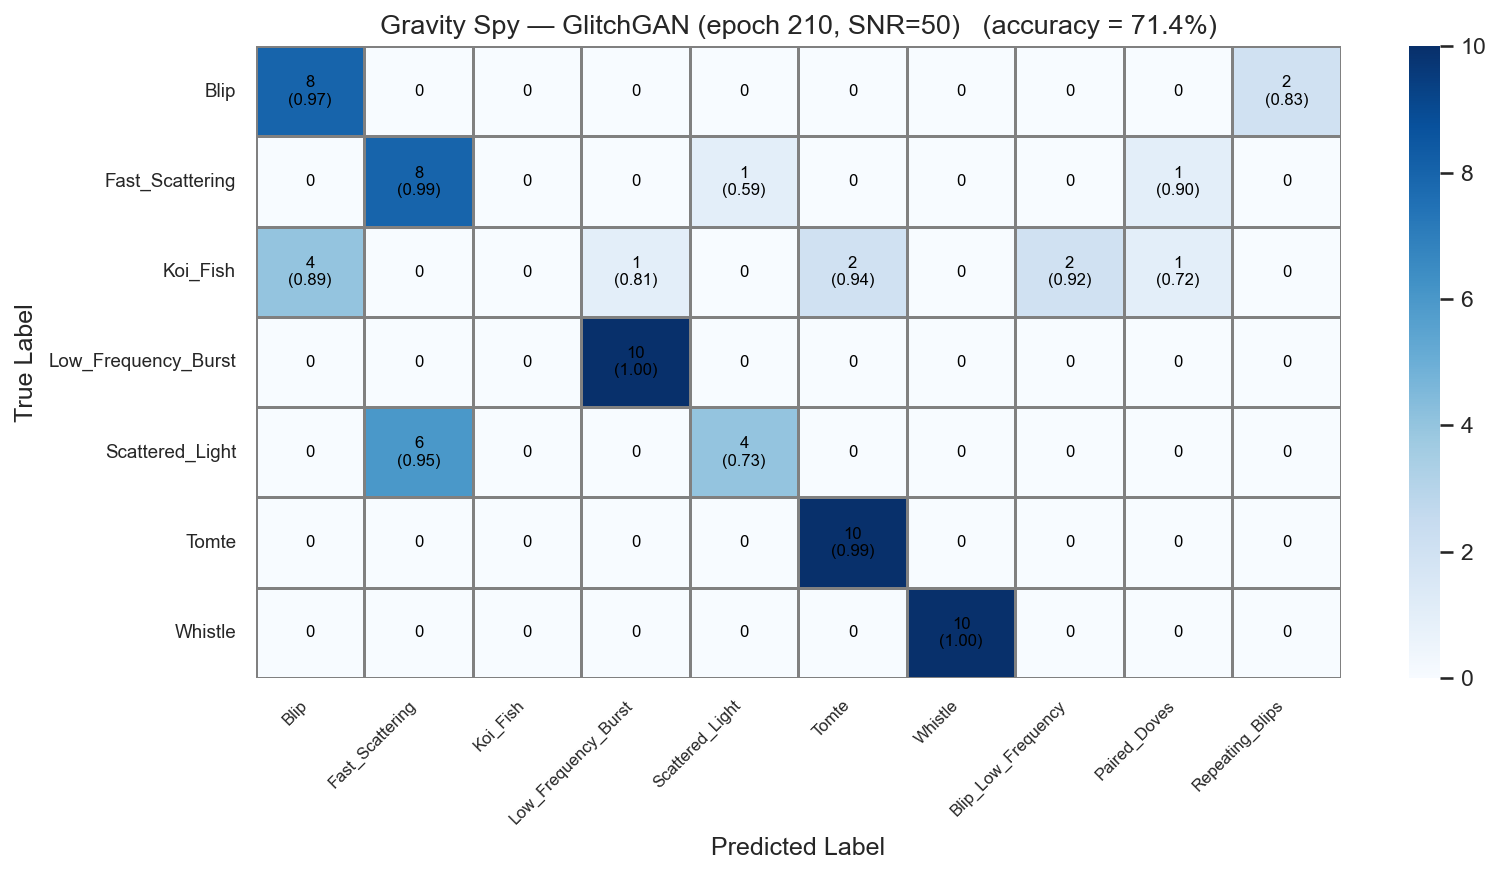

GlitchGAN (epoch 210, SNR=50) accuracy: 0.714


In [7]:
acc = plot_confusion(df, f'GlitchGAN (epoch 210, SNR={SNR_TARGET})', 'gspy_cm')